# I - Imports and Setup

In [1]:
# Import libraries
import os
import numpy as np                                      
import pandas as pd                                    
import scipy.stats as stats                            
import matplotlib.pyplot as plt                        
import seaborn as sns                                   
import plotly.graph_objects as go                       

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder   
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split                                      
from sklearn import datasets                                                      
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
# Setting up the root directory
root_dir = r"C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition"

os.chdir(root_dir)

# Sanity check
print(os.getcwd())          # shows current notebook directory
print(os.listdir('data'))   # shows contents of the Data folder

C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition
['processed', 'raw']


# II- Data Exploration

## A) Loading the data

In [3]:
# Setting up the root directory
train = pd.read_csv('data/raw/train.csv', index_col=0, low_memory=False)
train_labels = pd.read_csv('data/raw/train_labels.csv', index_col=0, low_memory=False)
test = pd.read_csv('data/raw/test.csv', index_col=0, low_memory=False)

We verify that the data was loaded correclty

In [6]:
train.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
502504,0,0,0,0,6,0,0.0,0,0,0,...,NaN,NaN,Y562h9T,NaN,Q8_a,Xjzr,NaN,NaN,NaN,NaN
197332,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,NyGn9rV,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN
277830,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,Kbs60Tf,NaN,Q8_a,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN


In [7]:
train_labels.head(3)

,Target_appetency
ID,
502504,0
197332,0
277830,0


In [8]:
test.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
877149,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,oHCnpDP,NaN,KttQ,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN
109603,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,WHgQeH3,NaN,KttQ,lGxM0UqL0k,NaN,NaN,NaN,NaN
560424,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,COVmcoL,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN


## B) Data Exploration

We performing some basic Data Exploration to understand the data we are working with and to detect some potential issues

### 1 - Exploration Function

In [14]:
def explore(dataset, name = "dataset"):
    print(f'{name} set : ')
    # Shape
    print(f'Rows: {dataset.shape[0]}')
    print(f'Columns : {dataset.shape[1]}')
    # Dtypes
    print(f'\nDtypes breakdown:')
    print(dataset.dtypes.value_counts())
    # Columns type
    num_cols = dataset.select_dtypes(include='number').columns
    cat_cols = dataset.select_dtypes(include='object').columns
    
    print(f"\nNumeric columns : {len(num_cols)}")
    print(f"Categorical cols: {len(cat_cols)}")

    # Check for duplicates
    duplicates = dataset.duplicated().sum()
    print(f'\nDuplicates : {duplicates}')

    # Missing values
    miss = dataset.isna().sum().sum()
    print('\n% Missing : ', miss/dataset.size*100 )

### 2 - Inspection

In [15]:
# Train set
explore(train, name = "Train")

Train set : 
Rows: 30000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64

Numeric columns : 14811
Categorical cols: 189

Duplicates : 0

% Missing :  3.3485435555555556


In [16]:
# Train Labels
explore(train_labels, name='Train Labels')

Train Labels set : 
Rows: 30000
Columns : 1

Dtypes breakdown:
int64    1
Name: count, dtype: int64

Numeric columns : 1
Categorical cols: 0

Duplicates : 29998

% Missing :  0.0


In [17]:
# Test set
explore(test, name = 'Test')

Test set : 
Rows: 20000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64

Numeric columns : 14811
Categorical cols: 189

Duplicates : 0

% Missing :  3.3467076666666666


### 3 - Data Types

We notice that we only have 189 categorical variables.  
However, according to the data description, we are suposed to find 260 categorical variables.  
Hence, we need to check where the problem is and correct the problem accordingly

We can see that some of these features are casted as floats. We need to cast them back as objects

In [4]:
# We verify the dtype of the 260 categorical variables
print('Train : ' , train.iloc[:, 14740:].dtypes.unique())
print('Test : ', test.iloc[:, 14740:].dtypes.unique())

Train :  [dtype('O') dtype('float64')]
Test :  [dtype('O') dtype('float64')]


In [5]:
# Casting to the correct data type
for df in [train, test]:
    df[df.columns[14740:]] = df[df.columns[14740:]].astype('object')

In [6]:
# Checking 
print('Train : ' , train.iloc[:, 14741:].dtypes.unique())
print('Test : ', test.iloc[:, 14741:].dtypes.unique())

Train :  [dtype('O')]
Test :  [dtype('O')]


We verify that we have the right distrobution of dtypes

In [7]:
# Train set
train.dtypes.value_counts()

int64      13414
float64     1326
object       260
Name: count, dtype: int64

In [8]:
# Test set
test.dtypes.value_counts()

int64      13414
float64     1326
object       260
Name: count, dtype: int64

### 4 - Class Balance

C:\Users\Source\AppData\Local\Temp\ipykernel_35860\1973376753.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dist_pct,


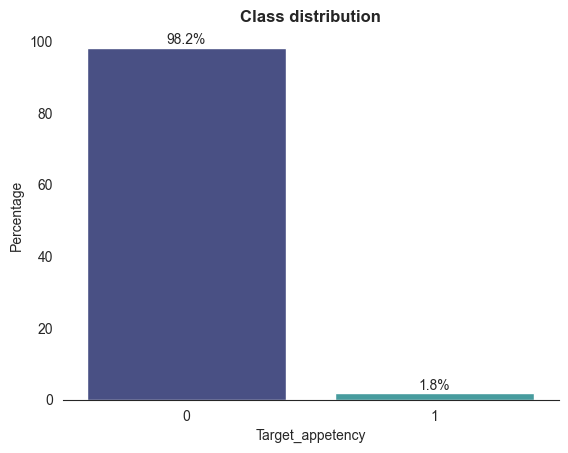

In [28]:
# Checking class balance
dist_pct =  train_labels['Target_appetency'].value_counts(normalize=True) * 100
dist_pct = dist_pct.reset_index()
dist_pct.columns = ['Target_appetency', 'Percentage']

sns.set_style("white")

ax = sns.barplot(data=dist_pct,
            x = 'Target_appetency',
            y = 'Percentage',
            palette='mako')

# Adding values to each bar
for p in ax.patches:
    ax.text(x=p.get_x() + p.get_width()/2,  # center of bar
            y=p.get_height() + 1,   # a bit above the bar
            s=f'{p.get_height():.1f}%',  # text
            ha='center')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


plt.title('Class distribution', fontweight='bold')
plt.show()

We notice that the data is **highly imbalanced.**   

This is common in classification problems and can cause issues in modeling (majority class bias)  

This will be handled later when modeling using various techniques

# III -  Cleaning

Eery decision is derived from the **training set only**, then applied
identically to the test set.  This is the only way to prevent test-distribution
leakage into the preprocessing pipeline.

## A) High Missing

In [9]:
# Initial Shape (for comparison)
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (30000, 15000)
Test: (20000, 15000)


In [10]:
# Defining the missing threshold 
miss_tsh = 50

train_missing_pct = train.isna().mean() * 100
cols_to_drop_missing = train_missing_pct[train_missing_pct >= miss_tsh].index.tolist()

print(f"Columns with ≥{miss_tsh}% missing in train : {len(cols_to_drop_missing)}")
print(f"of which 100% missing : {(train_missing_pct == 100).sum()}")

# errors='ignore' handles the 1 column (Var10906) that is 100% missing only in test
train.drop(columns=cols_to_drop_missing, inplace=True)
test.drop(columns=cols_to_drop_missing, errors='ignore', inplace=True)

# Checking the new shape of the data 
print(f"\nTrain: {train.shape}")
print(f"Test: {test.shape}")

Columns with ≥50% missing in train : 526
of which 100% missing : 109

Train: (30000, 14474)
Test: (20000, 14474)


## B) Imputing 

Dimensionality is the main constraint we have here.
Adding add_indicator=True (to keep the trace of missing) would add up to 14 000 extra binary columns(one per
feature that has missingness) at fit time, which will hurt almost every model
in our benchmark.

**By model:**
- **Tree-based :** no flag needed. Splits on median-imputed
  values naturally cluster missing observations at the same cutpoint; the model recovers
  the signal implicitly.
- **LDA / QDA:** flags violate the Gaussian class-conditional assumption and corrupt
  the covariance matrix estimate.
- **KNN:** extra binary dimensions add noise to every pairwise distance in an already
  high-dimensional space (curse of dimensionality).
- **SVM / SVC:** sparse binary columns dilute kernel similarity and inflate training cost.
- **Logistic Regression:** flags would ideally help ), but the multicollinearity and regularisation cost outweighs the benefit
  at this scale.
- **Neural Network:** dropout and weight regularisation handle imputed values without
  explicit flags at this feature count.

**Conclusion:** the one model family that could benefit (linear) is precisely the one
where the dimensionality cost is highest. We proceed without flags across the full pipeline.

In [11]:
# Defining and seperating our different columns agains
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

# Numerical imputation by median
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(train[num_cols])  # fit on train ONLY

train[num_cols] = num_imputer.transform(train[num_cols])
test[num_cols]= num_imputer.transform(test[num_cols])

# Categorical imputation with a 'Missing' constant
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
cat_imputer.fit(train[cat_cols])  # fit on train ONLY

train[cat_cols] = cat_imputer.transform(train[cat_cols])
test[cat_cols]  =cat_imputer.transform(test[cat_cols])

# Sanity check
print(f"Remaining nulls in train: {train.isna().sum().sum()}")
print(f"Remaining nulls in test: {test.isna().sum().sum()}")

Remaining nulls in train: 0
Remaining nulls in test: 0


# IV - Variance Filtering

In [ ]:
# CONSTANT + NEAR-CONSTANT FEATURE REMOVAL (0.995 threshold)

threshold = 0.995

low_variance_cols = []

for col in train.columns:
    top_freq = train[col].value_counts(normalize=True, dropna=False).max()
    
    if top_freq >= threshold:
        low_variance_cols.append(col)

print(f"Columns to drop (constant and near-constant): {len(low_variance_cols)}")

# Drop
train.drop(columns=low_variance_cols, inplace=True)
test.drop(columns=low_variance_cols, errors='ignore', inplace=True)

# Check
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Columns to drop (constant and near-constant): 9420
Train: (30000, 5054)
Test: (20000, 5054)


# V - Categorical Enconding

In [13]:
# Recompute categorical columns after dropping columns
cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cardinality = train[cat_cols].nunique().sort_values(ascending=False)

print(cat_cardinality.describe())

# Checking the cardinaties
print(f"\nDistribution:")
print(f"  1-5 unique values:   {(cat_cardinality <= 5).sum()}")
print(f"  6-10 unique values:  {((cat_cardinality > 5) & (cat_cardinality <= 10)).sum()}")
print(f"  11-20 unique values: {((cat_cardinality > 10) & (cat_cardinality <= 20)).sum()}")
print(f"  21-50 unique values: {((cat_cardinality > 20) & (cat_cardinality <= 50)).sum()}")
print(f"  50+ unique values:   {(cat_cardinality > 50).sum()}")

print(f"\nTop 10 highest cardinality:")
print(cat_cardinality.head(10))

count       35.000000
mean       923.114286
std       2180.027763
min          2.000000
25%          4.500000
50%         13.000000
75%        157.000000
max      10654.000000
dtype: float64

Distribution:
  1-5 unique values:   10
  6-10 unique values:  5
  11-20 unique values: 3
  21-50 unique values: 6
  50+ unique values:   11

Top 10 highest cardinality:
Var14822    10654
Var14913     5264
Var14904     3628
Var14993     3375
Var14893     3375
Var14797     3375
Var14795     1635
Var14788      344
Var14965      214
Var14786      100
dtype: int64


Given the very high cardinality of some columns, we will differentiate between low carsinality, which we defined as <= 20 , and high cardinality (>=20).

OHE will be conducted on low card only 

Frequency encoding will be conducted on high card

In [14]:
# Split by cardinality 
low_card_cols  = [c for c in cat_cols if train[c].nunique() <= 20]
high_card_cols = [c for c in cat_cols if train[c].nunique() >  20]

print(f"Low cardinality :{len(low_card_cols)} columns")
print(f"High cardinality : {len(high_card_cols)} columns")

# OHE - fit on train only
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(train[low_card_cols])

ohe_train = pd.DataFrame(ohe.transform(train[low_card_cols]), columns=ohe.get_feature_names_out(low_card_cols), index=train.index)
ohe_test = pd.DataFrame(ohe.transform(test[low_card_cols]),columns=ohe.get_feature_names_out(low_card_cols),index=test.index)

# Frequency encoding- computed on train only
freq_train = pd.DataFrame(index=train.index)
freq_test = pd.DataFrame(index=test.index)

for col in high_card_cols:
    freq_map = train[col].value_counts(normalize=True) 
    freq_train[f"{col}_freq"] = train[col].map(freq_map)
    # unseen categories in test get 0 (genuinely unknown frequency)
    freq_test[f"{col}_freq"]  = test[col].map(freq_map).fillna(0)


# Dropping the original columns and adding the new encoded ones
train.drop(columns=cat_cols, inplace=True)
test.drop(columns=cat_cols,  inplace=True)

train = pd.concat([train, ohe_train, freq_train], axis=1)
test = pd.concat([test, ohe_test,  freq_test],  axis=1)

#aligning the columns
test = test.reindex(columns=train.columns, fill_value=0)

Low cardinality :18 columns
High cardinality : 17 columns


c:\Users\Source\.conda\envs\sml\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [15]:
# Sanity Check
print(f"\nTrain: {train.shape}")
print(f"Test: {test.shape}")
print(f"Column mismatch: {(train.columns != test.columns).sum()}")


Train: (30000, 5123)
Test: (20000, 5123)
Column mismatch: 0


# VI - Exporting the Data

Exporting the clean tables to our processed folder

In [ ]:
train.to_csv('data/processed/train_preprocessed.csv', index=False)
test.to_csv('data/processed/test_preprocessed.csv', index=False)
train_labels.to_csv('data/processed/y_train.csv', index=False)

print(f"Final train: {train.shape}")
print(f"Final test: {test.shape}")

## Val set & Feature selection

**Note that we do not include a validation set as we are going to use k-fold cross-validation in our modeling**

**Also, No feature selection in SUPERVISED preprocessing. All feature supervised selection is performed inside each model’s Pipeline, as applying supervised feature selection (mutual information) before CV would use the full training set, causing leakage into validation folds. Thus, we only used UNSUPERVISED feature filtering such as missing filtering and variance filtering**


# End of the preprocessing notebook